Данный датасет содержит информацию по проведенному А\Б тесту среди пользователей игры cookie cats
Колонки:
1. ID пользователя
2. В какую тестовую группу попал пользователь
3. Количество раундов, сыгранное пользователем
4. Вернулся ли пользователь на следующий день после установки
5. Вернулся ли пользователь через неделю после установки

Мои цели на данный датасет:
1. Провести EDA и рассчитать доступные по данным метрики. Это нужно, чтобы привести данные в порядок и убрать возможные аномалии\пропуски, оценить поведение пользователей до А\Б теста
2. Определить характер распределения и рассчитать вероятности, чтобы выбрать статистический критерий для тестирования и чтобы глубже понять паттерн вовлеченности аудитории
3. Подтвердить гипотезы.
   Гипотеза 1: Перенос ворот с 30-ого уровня на 40-ой положительно повлиял на удержание пользователей
   Гипотеза 2: Перенос ворот с 30-ого уровня на 40-ой положительно повлиял на кол-во сыгранных раундов
4. Сделать выводы на основе проведенного анализа и получить ответ, стоит ли оставлять введённое изменение

Сначала выведем первые несколько строк датасета, чтобы посмотреть как выглядят данные и общая структура

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

df = pd.read_csv('cookie_cats.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


Выведем общую информацию, чтобы увидеть количество заполненных строк и типы данных

In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB
None


Попробуем найти пропуски

In [3]:
df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

 Попробуем найти дубликаты строк

In [4]:
df.duplicated().sum()

np.int64(0)

Посмотрим распределение на группы по количеству, а так же проверим, есть ли другие значения

In [5]:
df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Посмотрим уникальные ли пользователи

In [6]:
print(df.shape)
df['userid'].nunique()

(90189, 5)


90189

проверим значения в булевых столбцах, есть ли другие значения

In [7]:
print(df['retention_1'].value_counts())
df['retention_7'].value_counts()

retention_1
False    50036
True     40153
Name: count, dtype: int64


retention_7
False    73408
True     16781
Name: count, dtype: int64

посмотрим на статистику по столбцу количества сыгранных пользователями раундов

In [8]:
df['sum_gamerounds'].describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Есть слишком большое значение 49854 сыгранных раундов, пользователь не мог столько сыграть, нужно удалить строку с этим значением

In [9]:
df = df[df['sum_gamerounds'] != 49854]
df['sum_gamerounds'].describe()

count    90188.000000
mean        51.320253
std        102.682719
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max       2961.000000
Name: sum_gamerounds, dtype: float64

Теперь визуализируем распределение активности пользователей с помощью ящика с усами, потому что describe сам по себе не дает полной картины

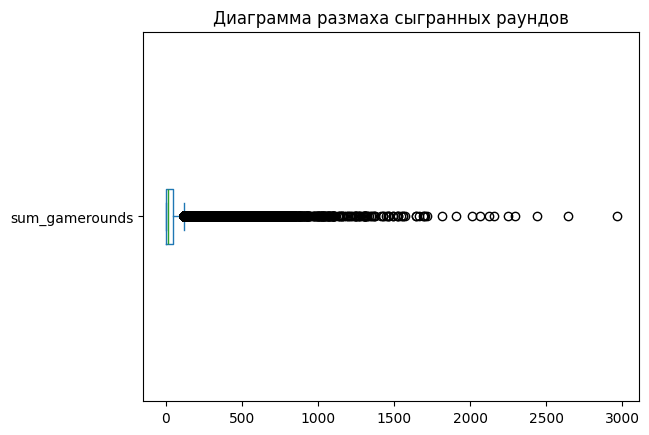

In [10]:
df['sum_gamerounds'].plot(kind='box', vert=False)
plt.title('Диаграмма размаха сыгранных раундов')
plt.show()

На графике видно, что слишком много пользователей, которые сыграли 500+ раундов, он нечитаем. Поэтому сделаем дополнительный график, где ограничим
количество раундов значением 100.

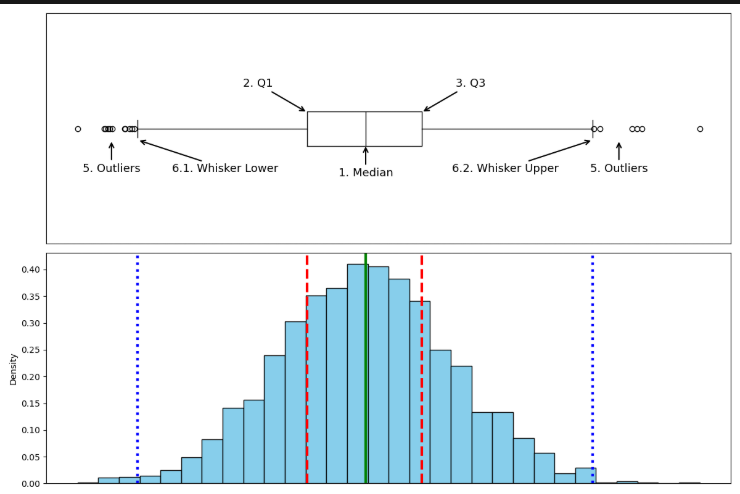

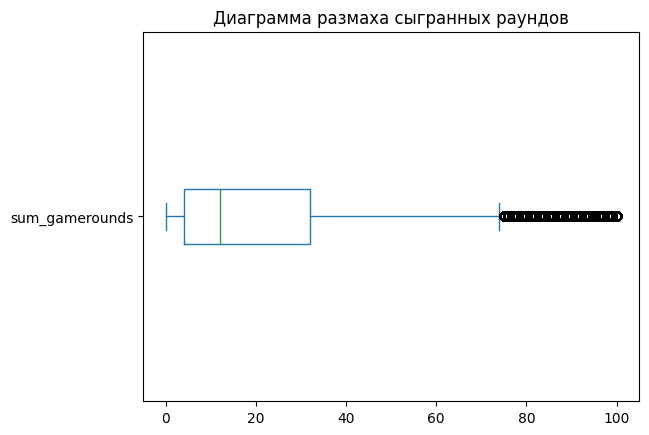

In [11]:
game_rounds_300 = df[df['sum_gamerounds'] <= 100]
game_rounds_300['sum_gamerounds'].plot(kind='box', vert=False)
plt.title('Диаграмма размаха сыгранных раундов')
plt.show()

Медианное количество сыгранных раундов - это 16.
Разброс значений до выбросов от 0 до ~76.
25 процентов пользователей играет всего 0-5 раундов, а 25 процентов пользователей играю больше ~33 раундов
Та как медиана - 16 раундов, значит более половины пользователей вообще никогда не видит ворот и им не важно передвижение с 30 до 40 уровня.
Получается, что изменение затронет только вовлечённых уже игроков

Давайте так же найдем процент людей в обеих группах, кто вообще не играет в игру. Если он будет сильно отличаться, то возможно что-то не так в одной из версий игры.

In [12]:
df_zero_30 = df[(df['sum_gamerounds'] == 0)  & (df['version'] == 'gate_30')]
df_zero_40 = df[(df['sum_gamerounds'] == 0)  & (df['version'] == 'gate_40')]
print(f'размеры для группы 30: {df_zero_30.shape}', f'размеры для группы 40: {df_zero_40.shape}', sep='\n')

размеры для группы 30: (1937, 5)
размеры для группы 40: (2057, 5)


Видим, что почти одинаковое количество человек попало в обе группы
Теперь посчитаем % от общего кол-ва

In [13]:
percentage_of_30 = round(len(df_zero_30) / len(df) * 100, 2)
percentage_of_40 = round(len(df_zero_40) / len(df) * 100, 2)
print(f'Игроков с нулем раундов из группы 30 - {percentage_of_30} %', f'Игроков с нулем раундов из группы 40 - {percentage_of_40} %', sep='\n')

Игроков с нулем раундов из группы 30 - 2.15 %
Игроков с нулем раундов из группы 40 - 2.28 %


Получаем равномерно распределенные группы.
Так как тестирование находится на 30-40 уровнях, можно сделать вывод, что поведение этой когорты игроков не связано с влиянием А\Б теста.

Проведём группировку и сравнение метрик по тестовым группам. Это поможет понять в какую сторону изменились метрики.


In [14]:
df_grouped = df[['version', 'sum_gamerounds', 'retention_1', 'retention_7']].groupby('version').agg({'sum_gamerounds': ['mean','median'],
                                                                                                     'retention_1': ['mean'],
                                                                                                     'retention_7': ['mean']})
df_grouped[('sum_gamerounds', 'mean')] = round(df_grouped[('sum_gamerounds', 'mean')], 2)
df_grouped[('retention_1', 'mean')] = round(df_grouped[('retention_1', 'mean')] * 100, 2)
df_grouped[('retention_7', 'mean')] = round(df_grouped[('retention_7', 'mean')] * 100, 2)
df_grouped

sum_gamerounds        retention_1 retention_7
                  mean median        mean        mean
version                                              
gate_30          51.34   17.0       44.82       19.02
gate_40          51.30   16.0       44.23       18.20

Сравнение метрик по А\Б группам:
ретеншн первого дня упал на 0.6 процента
ретеншн седьмого дня упал на 0.8 процента
медианное число раундов снизилось с 17 до 16

Предварительный вывод: отодвигание ворот не увеличило вовлеченность игроков, а слегка её снизило. Нужно проверить статистичискую значимость этих данныхю

Интересно еще посмотреть, кто вернется и в первый и в седьмой день среди всей аудитории

In [15]:
retention_1_true = df[df['retention_1'] == True]
ret_1_len = len(retention_1_true)
retention_7_true = retention_1_true[retention_1_true['retention_7'] == True]
ret_7_len = len(retention_7_true)
constant_players = round(ret_7_len / ret_1_len * 100, 1)
print(f'Процент игроков, кто вернулся в 1 и 7 дни - {constant_players} %')

Процент игроков, кто вернулся в 1 и 7 дни - 32.8 %


Таким образом условная вероятность удержания игрока составляет  32.8 %
Почти треть пользователей продолжает играть спустя неделю

Протестируем гипотезу 1.
Удержание является бинарной метрикой, то есть вернулся=1, не вернулся=0.
Для сравнения конверсий в двух независимых группах используем Z критерий.
Сформулируем статистическую гипотезу H_0: Доли вернувшихся пользователей в группах равны. Перенос не повлиял на удержание.
H_1: Доли вернувшихся пользователей различаются
Уровень значимости alpha = 0.05

Подготовим данные для теста для 1-го и 7-го дней отдельно:
1. Количество успешных возвращений
2. Общее количество пользователей в группе

In [28]:
#Количество успешных возвращений по 1 дню
success_1_30 = len(df[(df['retention_1'] == True) & (df['version'] == 'gate_30')])
success_1_40 = len(df[(df['retention_1'] == True) & (df['version'] == 'gate_40')])

#Количество успешных возвращений по 7 дню
success_7_30 = len(df[(df['retention_7'] == True) & (df['version'] == 'gate_30')])
success_7_40 = len(df[(df['retention_7'] == True) & (df['version'] == 'gate_40')])

#Общее количество пользователей в группе
n_30 = len(df[df['version'] == 'gate_30'])
n_40 = len(df[df['version'] == 'gate_40'])

Проведем статистический тест с помощью statsmodels на данных, которые посчитали выше и получим вероятность различий

In [31]:
alpha = 0.05

#Тест для 1 дня
counts_1 = np.array([success_1_30, success_1_40])
nobs = np.array([n_30, n_40])

stat_1, pval_1 = proportions_ztest(counts_1, nobs)
print(f"Значение вероятности для удержания 1-го дня: {pval_1:.4f}")

if pval_1 < alpha:
    print("Отвергаем H0: Разница в удержании 1-го дня статистически значима.")
else:
    print("Не отвергаем H0: Разница в удержании 1-го дня случайна.")


#Тест для 7 дня
counts_7 = np.array([success_7_30, success_7_40])
stat_7, pval_7 = proportions_ztest(counts_7, nobs)
print(f"Значение вероятности для удержания 7-го дня: {pval_7:.4f}")

if pval_7 < alpha:
    print("Отвергаем H0: Разница в удержании 7-го дня статистически значима.")
else:
    print("Не отвергаем H0: Разница в удержании 7-го дня случайна.")

Значение вероятности для удержания 1-го дня: 0.0744
Не отвергаем H0: Разница в удержании 1-го дня случайна.
Значение вероятности для удержания 7-го дня: 0.0016
Отвергаем H0: Разница в удержании 7-го дня статистически значима.


Выводы.
Удержание 1-го дня - разница не является статистически значимой, изменение не оказало математически доказуемого влияния на краткосрочное удержание.
Удержание 7-го дня - выявлено статистически значимое снижение метрики в тестовой группе. Сдвиг ворот с 30 до 40 уровня негативно сказывается на долгосрочном возврате. Игроки, доходящие до 40-го уровня без пауз, скорее всего, быстрее выгорают, теряют интерес и уходят

Тестируем гипотезу 2 про количество раундов.
Это непрерывная метрика, т.к. у нас распределение не нормальное и с длинным хвостом, то используем критерий Манна-Уитни.
Сформулируем статистическую гипотезу H_0: распределения количества сыгранных раундов в двух группах равны.
H_1: Распределения различаются.


Раздлеим данные по раунам для групп и проведем тест

In [34]:
from scipy.stats import mannwhitneyu

alplha = 0.05

rounds_30 = df[df['version'] == 'gate_30']['sum_gamerounds']
rounds_40 = df[df['version'] == 'gate_40']['sum_gamerounds']

#Сам тест
stat, pval_m = mannwhitneyu(rounds_30, rounds_40, alternative='two-sided')
print(f"P-value для количества сыгранных раундов: {pval_m:.4f}")

if pval_m < alpha:
    print("Отвергаем H0: Разница в количестве раундов статистически значима.")
else:
    print("Не отвергаем H0: Разница в количестве раундов случайна.")

P-value для количества сыгранных раундов: 0.0502
Не отвергаем H0: Разница в количестве раундов случайна.


In [ ]:
Получаем пограничное значение, поэтому проведем еще пару таких тестов с циклом 

95% Доверительный интервал разницы средних: от -0.973 до 4.054


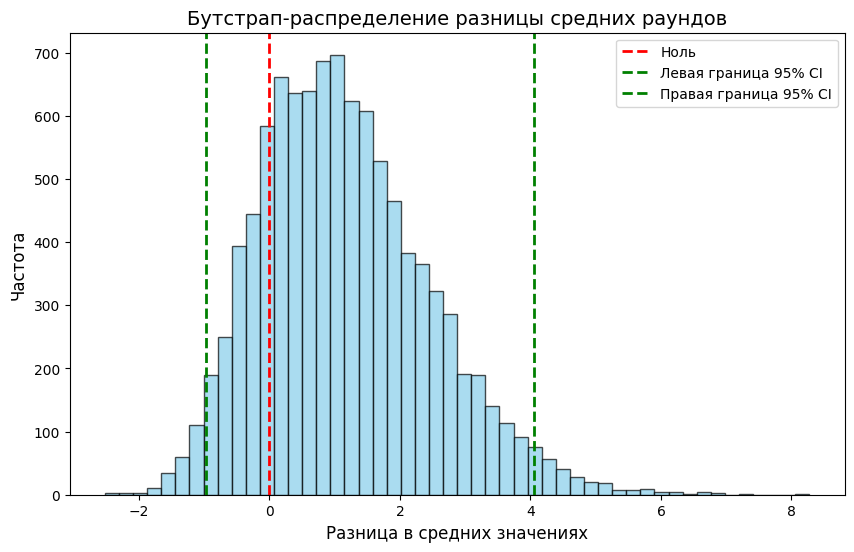

In [37]:
rounds_30 = df[df['version'] == 'gate_30']['sum_gamerounds'].values
rounds_40 = df[df['version'] == 'gate_40']['sum_gamerounds'].values
iterations = 10000
boot_diffs = []

for i in range(iterations):
    # Извлекаем случайные подвыборки с возвращением
    boot_30 = np.random.choice(rounds_30, size=len(rounds_30), replace=True)
    boot_40 = np.random.choice(rounds_40, size=len(rounds_40), replace=True)
    
    # Считаем разницу средних значений
    diff = boot_30.mean() - boot_40.mean()
    boot_diffs.append(diff)

# 4. Считаем 95% доверительный интервал
ci_left = np.percentile(boot_diffs, 2.5)
ci_right = np.percentile(boot_diffs, 97.5)

print(f"95% Доверительный интервал разницы средних: от {ci_left:.3f} до {ci_right:.3f}")

plt.figure(figsize=(10, 6))
plt.hist(boot_diffs, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Ноль')
plt.axvline(x=ci_left, color='green', linestyle='--', linewidth=2, label='Левая граница 95% CI')
plt.axvline(x=ci_right, color='green', linestyle='--', linewidth=2, label='Правая граница 95% CI')

plt.title('Бутстрап-распределение разницы средних раундов', fontsize=14)
plt.xlabel('Разница в средних значениях', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend()
plt.show()

Так как ноль попадает в 95% доверительный интервал, мы не можем отклонить нулевую гипотезу.
Несмотря на то, что медиана упала с 17 до 16, дисперсия в данных настолько велика из-за задротов, что эта разница могла получиться случайно. Мы не можем со 100% утверждать, что активность гарантированно упала.

Бизнес-выводы:
1. удержание 1 дня снизилось с 44.8% до 44.2%, однако разница статистически не значима.
Это логично, так как в первый день большинство игроков не доходит до 30-го уровня.
2. Медианное количество раундов снизилось с 17 до 16. Тест Манна-Уитни показал пограничное значение , что говорит о сильном негативном тренде, пусть и находящемся на грани статистической значимости.
3. удержание 7 дня  снизилось с 19.0% до 18.2%. Разница статистически значима . Это доказывает, что перенос  гарантированно приводит к ускоренному оттоку активных пользователей на дистанции в одну неделю.

Продуктовые выводы и рекомендации:
1. Изначальное предположение о том, что перенос ворот на 10 уровней дальше увеличит продолжительность сессий и улучшит метрики, оказалось ошибочным. 
Данные демонстрируют строго обратный эффект.
2. Стена на 30-м уровне работала для игроков как полезная пауза. Она защищала от перенасыщения однообразным контентом и формировала привычку возвращаться в игру позже. Отсутствие этого барьера приводит к тому, что ядро аудитории проходит слишком много уровней залпом, быстрее выгорает и забрасывает приложение к седьмому дню.
3. Поскольку изменение нанесло математически доказанный вред долгосрочному возврату, при этом не показав роста игровой активности, рекомендуется оставить ворота на 30-м уровне.